In [1]:
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_ROOT = os.path.expanduser("~/pcam_outputs_prof_final")
RUNS_DIR = os.path.join(OUT_ROOT, "runs")

SCHEDULES = ["constant", "step", "cosine", "warm_restarts", "warmup_cosine"]
SEEDS = [42, 43, 44]

print("RUNS_DIR:", RUNS_DIR)


RUNS_DIR: /home/bontu/pcam_outputs_prof_final/runs


In [2]:
missing = []
for sch in SCHEDULES:
    for sd in SEEDS:
        d = os.path.join(RUNS_DIR, sch, f"seed{sd}")
        fm = os.path.join(d, "final_metrics.json")
        hs = os.path.join(d, "history.json")
        if not (os.path.exists(d) and os.path.exists(fm) and os.path.exists(hs)):
            missing.append((sch, sd, os.path.exists(d), os.path.exists(fm), os.path.exists(hs)))

if missing:
    print("MISSING RUNS/FILES:")
    for row in missing:
        print(row)
else:
    print("All 15 runs found with history.json + final_metrics.json ✅")


All 15 runs found with history.json + final_metrics.json ✅


In [3]:
rows = []
for sch in SCHEDULES:
    for sd in SEEDS:
        p = os.path.join(RUNS_DIR, sch, f"seed{sd}", "final_metrics.json")
        m = json.load(open(p))
        rows.append({
            "schedule": sch,
            "seed": sd,
            "val_acc": m["final_val"]["acc"],
            "val_f1": m["final_val"]["f1"],
            "val_auc": m["final_val"]["roc_auc"],
            "test_acc": m["final_test"]["acc"],
            "test_f1": m["final_test"]["f1"],
            "test_auc": m["final_test"]["roc_auc"],
        })

df = pd.DataFrame(rows)
df


,schedule,seed,val_acc,val_f1,val_auc,test_acc,test_f1,test_auc
0,constant,42,0.769958,0.712794,0.846540,0.753876,0.682892,0.890523
1,constant,43,0.861450,0.847538,0.944476,0.806854,0.772722,0.892504
2,constant,44,0.809906,0.771393,0.924204,0.765076,0.700816,0.885508
3,step,42,0.844543,0.824381,0.935559,0.777618,0.726001,0.885932
4,step,43,0.843506,0.822438,0.938020,0.775757,0.722884,0.881520
5,step,44,0.830658,0.805320,0.929048,0.780701,0.732006,0.876094
6,cosine,42,0.862396,0.847849,0.939228,0.794922,0.753449,0.890546
7,cosine,43,0.848297,0.829075,0.935476,0.781219,0.732849,0.868054
8,cosine,44,0.861908,0.847853,0.937711,0.791412,0.749018,0.887689
9,warm_restarts,42,0.840027,0.816995,0.931915,0.780701,0.729911,0.887403


In [4]:
def mean_std_str(x):
    return f"{np.mean(x):.4f} ± {np.std(x, ddof=1):.4f}"

table = []
for sch in SCHEDULES:
    sub = df[df["schedule"] == sch]
    table.append({
        "Schedule": sch,
        "Val Acc (mean±std)": mean_std_str(sub["val_acc"]),
        "Val F1 (mean±std)":  mean_std_str(sub["val_f1"]),
        "Val ROC-AUC (mean±std)": mean_std_str(sub["val_auc"]),
        "Test Acc (mean±std)": mean_std_str(sub["test_acc"]),
        "Test F1 (mean±std)":  mean_std_str(sub["test_f1"]),
        "Test ROC-AUC (mean±std)": mean_std_str(sub["test_auc"]),
    })

report_table = pd.DataFrame(table)
report_table


,Schedule,Val Acc (mean±std),Val F1 (mean±std),Val ROC-AUC (mean±std),Test Acc (mean±std),Test F1 (mean±std),Test ROC-AUC (mean±std)
0,constant,0.8138 ± 0.0459,0.7772 ± 0.0676,0.9051 ± 0.0517,0.7753 ± 0.0279,0.7188 ± 0.0475,0.8895 ± 0.0036
1,step,0.8396 ± 0.0077,0.8174 ± 0.0105,0.9342 ± 0.0046,0.7780 ± 0.0025,0.7270 ± 0.0046,0.8812 ± 0.0049
2,cosine,0.8575 ± 0.0080,0.8416 ± 0.0108,0.9375 ± 0.0019,0.7892 ± 0.0071,0.7451 ± 0.0108,0.8821 ± 0.0122
3,warm_restarts,0.8385 ± 0.0085,0.8152 ± 0.0118,0.9329 ± 0.0015,0.7763 ± 0.0040,0.7227 ± 0.0066,0.8837 ± 0.0059
4,warmup_cosine,0.8438 ± 0.0031,0.8224 ± 0.0044,0.9328 ± 0.0037,0.7725 ± 0.0023,0.7169 ± 0.0034,0.8791 ± 0.0067


In [5]:
out_csv = os.path.join(OUT_ROOT, "final_table_mean_std.csv")
report_table.to_csv(out_csv, index=False)
print("Saved:", out_csv)


Saved: /home/bontu/pcam_outputs_prof_final/final_table_mean_std.csv


In [6]:
def load_history(sch, sd):
    p = os.path.join(RUNS_DIR, sch, f"seed{sd}", "history.json")
    h = json.load(open(p))
    # ensure sorted by epoch
    h = sorted(h, key=lambda r: r["epoch"])
    return h

histories = {(sch, sd): load_history(sch, sd) for sch in SCHEDULES for sd in SEEDS}
max_epoch = max(histories[(SCHEDULES[0], SEEDS[0])][-1]["epoch"], 60)
print("Loaded histories. Example length:", len(histories[(SCHEDULES[0], SEEDS[0])]))


Loaded histories. Example length: 62


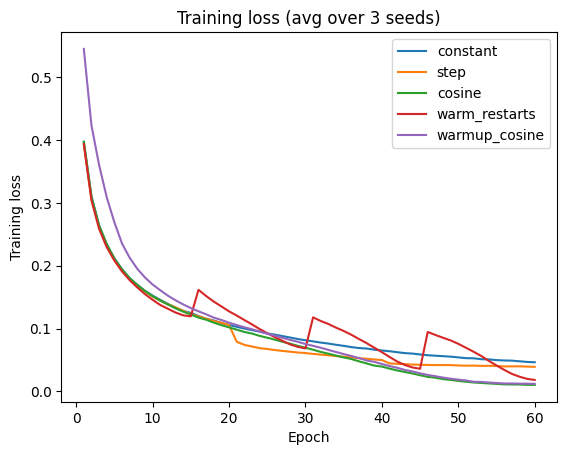

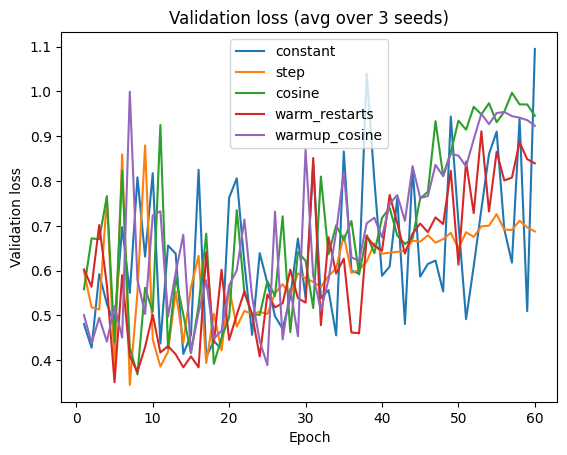

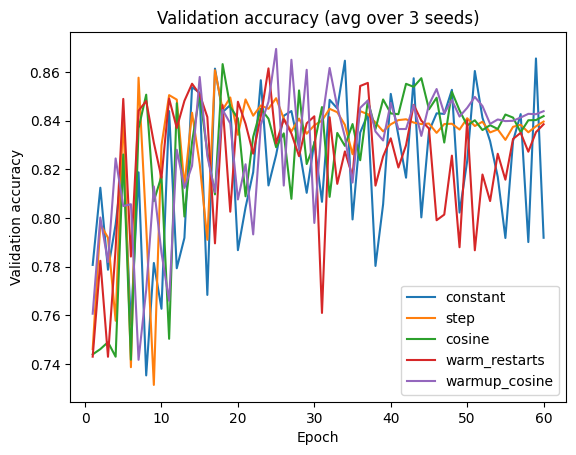

In [8]:
# Cell 6 — Learning curves overlay (train loss, val loss, val acc), averaged over seeds
# Fixes variable history lengths by aligning by epoch 1..60 and using nanmean.

import numpy as np
import matplotlib.pyplot as plt

epochs = list(range(1, 61))

def avg_curve(key, sch, max_epoch=60):
    mat = []
    for sd in SEEDS:
        h = histories[(sch, sd)]
        by_epoch = {row["epoch"]: row for row in h}  # epoch -> row
        vec = [by_epoch[e][key] if e in by_epoch else np.nan for e in range(1, max_epoch+1)]
        mat.append(vec)
    mat = np.array(mat, dtype=float)   # (3, 60)
    return np.nanmean(mat, axis=0)

# 1) Train loss
plt.figure()
for sch in SCHEDULES:
    y = avg_curve("train_loss", sch)
    plt.plot(epochs, y, label=sch)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training loss (avg over 3 seeds)")
plt.legend()
plt.show()

# 2) Val loss
plt.figure()
for sch in SCHEDULES:
    y = avg_curve("val_loss", sch)
    plt.plot(epochs, y, label=sch)
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss (avg over 3 seeds)")
plt.legend()
plt.show()

# 3) Val accuracy
plt.figure()
for sch in SCHEDULES:
    y = avg_curve("val_acc", sch)
    plt.plot(epochs, y, label=sch)
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy (avg over 3 seeds)")
plt.legend()
plt.show()



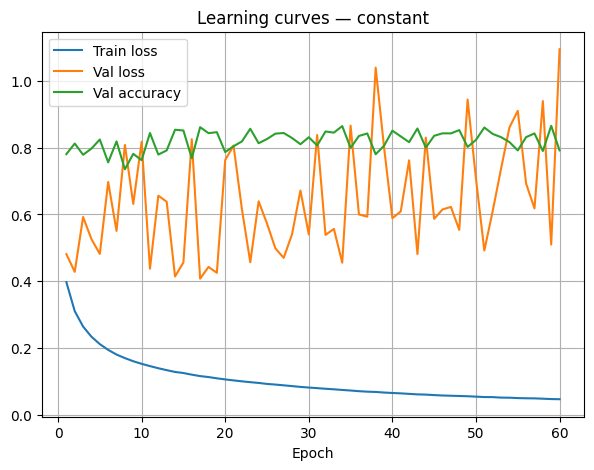

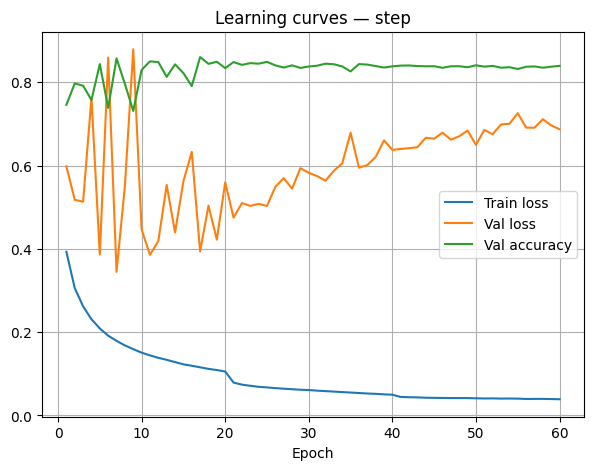

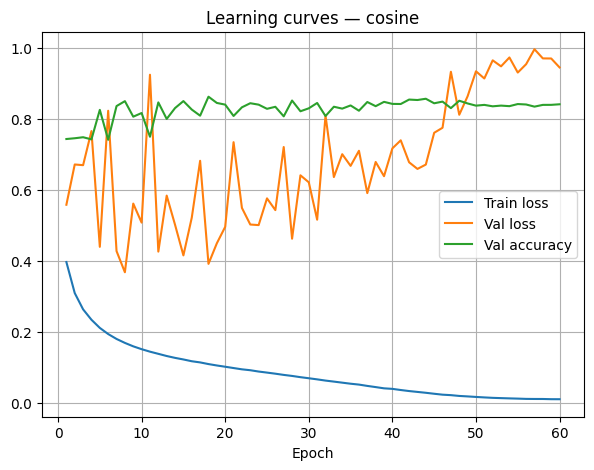

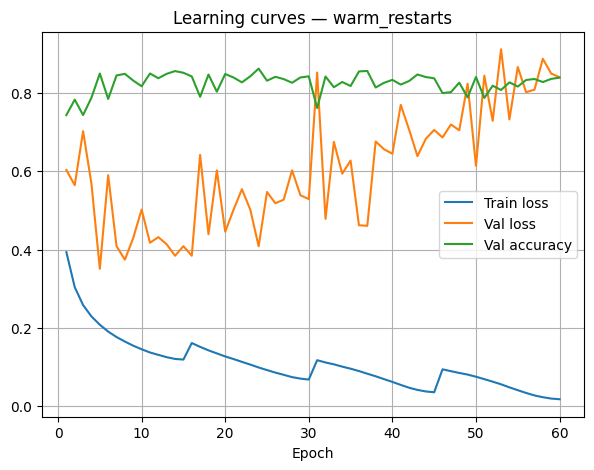

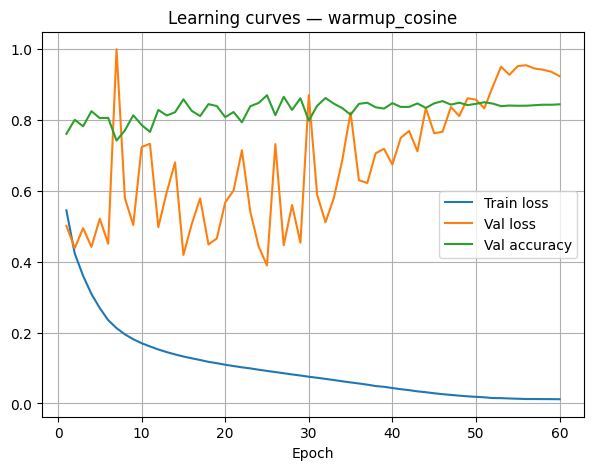

In [10]:
# Cell 6 — Learning curves per schedule (separate figures)

import numpy as np
import matplotlib.pyplot as plt

epochs = list(range(1, 61))

def avg_curve(key, sch, max_epoch=60):
    mat = []
    for sd in SEEDS:
        h = histories[(sch, sd)]
        by_epoch = {row["epoch"]: row for row in h}
        vec = [by_epoch[e][key] if e in by_epoch else np.nan for e in range(1, max_epoch+1)]
        mat.append(vec)
    mat = np.array(mat, dtype=float)
    return np.nanmean(mat, axis=0)

for sch in SCHEDULES:
    train_loss = avg_curve("train_loss", sch)
    val_loss   = avg_curve("val_loss", sch)
    val_acc    = avg_curve("val_acc", sch)

    plt.figure(figsize=(7,5))
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, val_loss, label="Val loss")
    plt.plot(epochs, val_acc, label="Val accuracy")
    plt.xlabel("Epoch")
    plt.title(f"Learning curves — {sch}")
    plt.legend()
    plt.grid(True)
    plt.show()


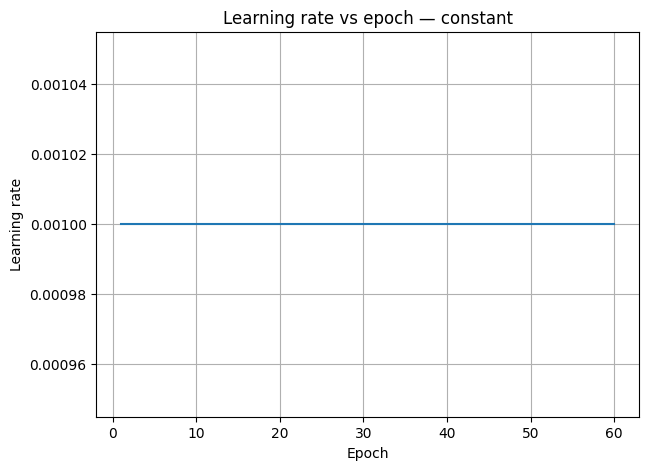

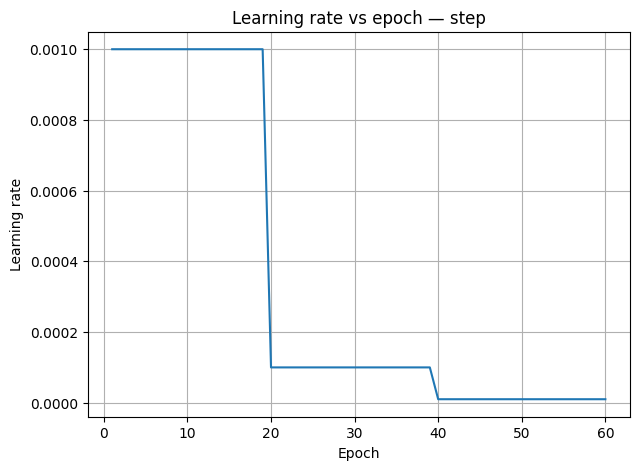

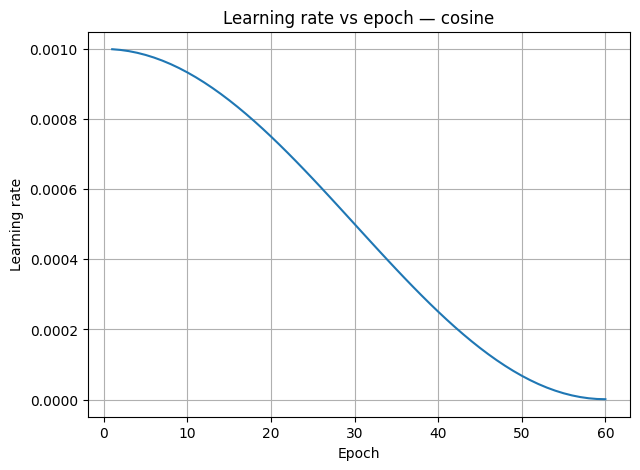

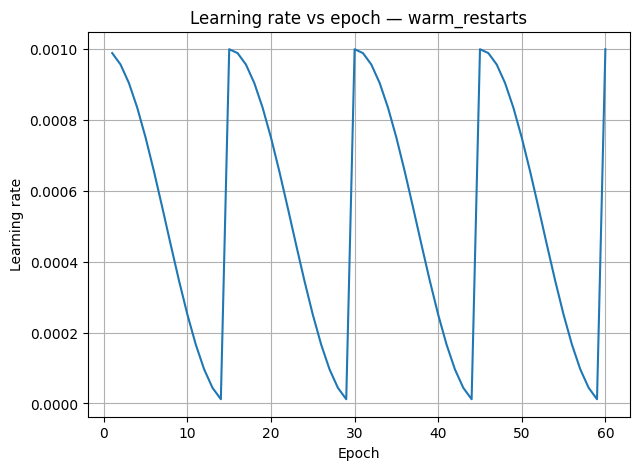

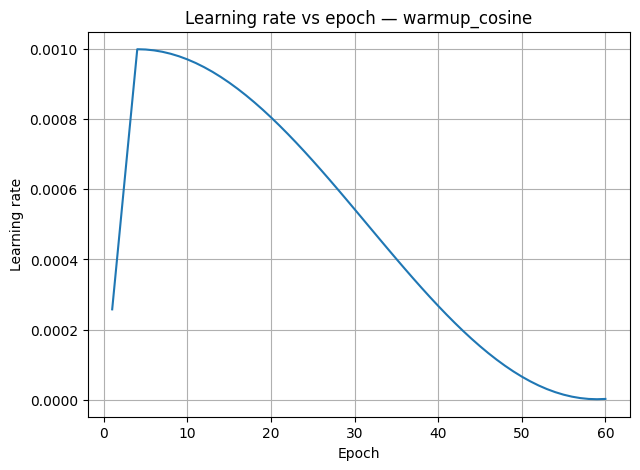

In [12]:
# Cell 7 — Learning rate vs epoch (per schedule, averaged over seeds)

epochs = list(range(1, 61))

def avg_lr(sch, max_epoch=60):
    mat = []
    for sd in SEEDS:
        h = histories[(sch, sd)]
        by_epoch = {row["epoch"]: row for row in h}
        vec = [by_epoch[e]["lr"] if e in by_epoch else np.nan for e in range(1, max_epoch+1)]
        mat.append(vec)
    mat = np.array(mat, dtype=float)
    return np.nanmean(mat, axis=0)

for sch in SCHEDULES:
    lr_curve = avg_lr(sch)
    plt.figure(figsize=(7,5))
    plt.plot(epochs, lr_curve)
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title(f"Learning rate vs epoch — {sch}")
    plt.grid(True)
    plt.show()

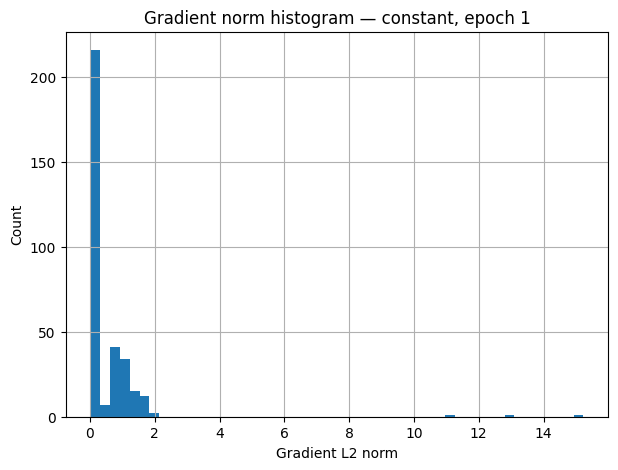

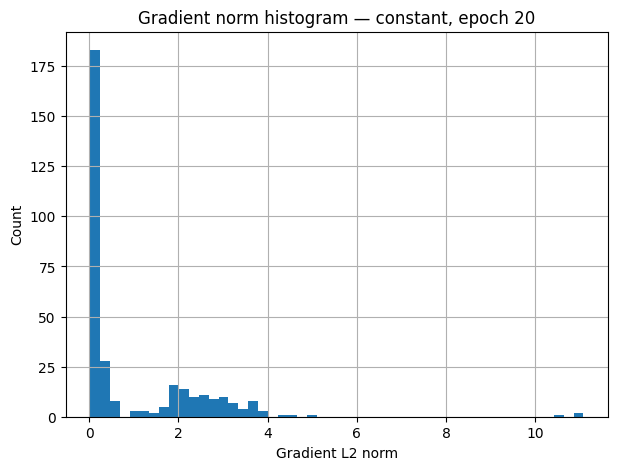

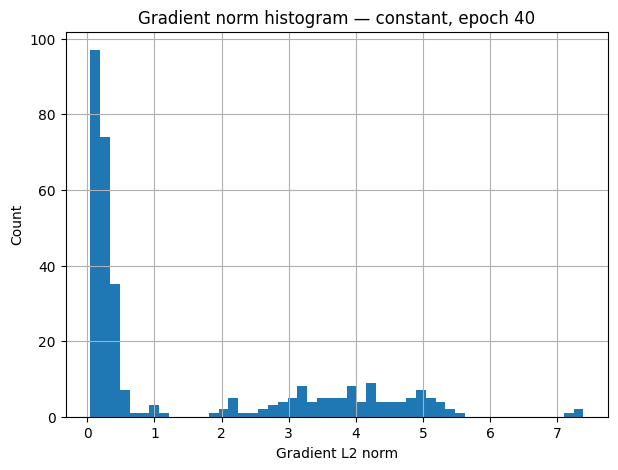

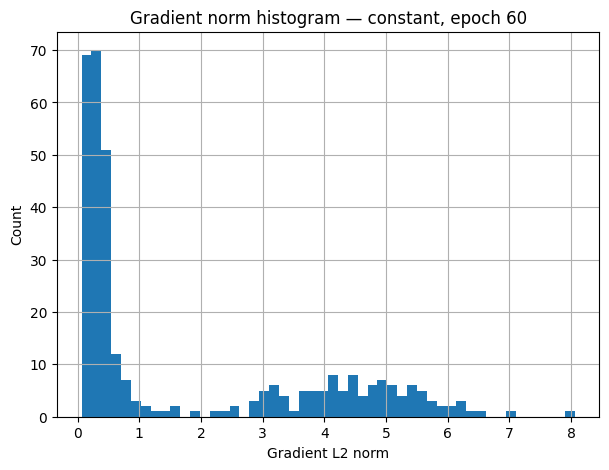

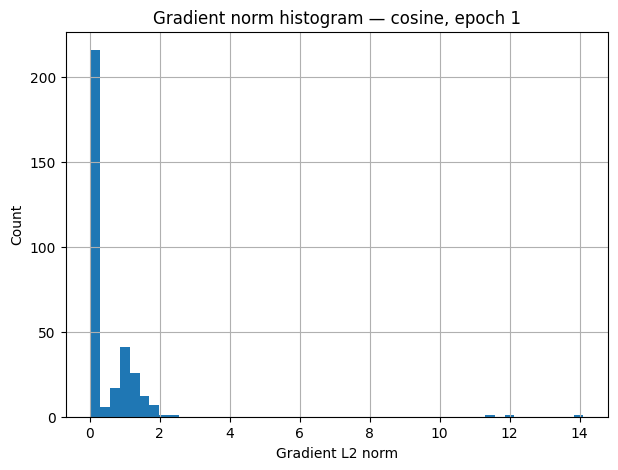

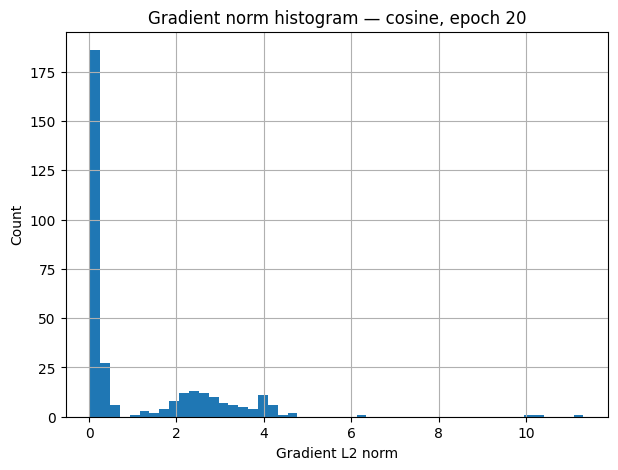

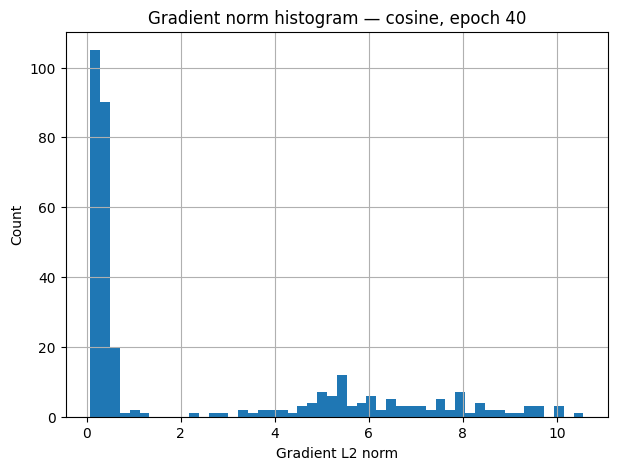

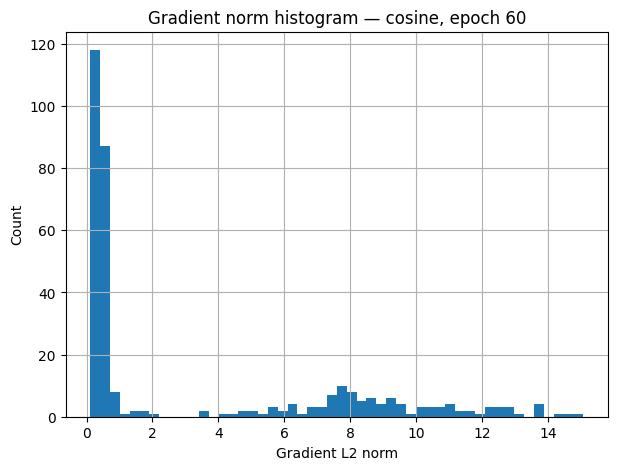

In [13]:
# Cell 8 — Gradient norm histograms (constant & cosine)

import json

GN_SCHEDULES = ["constant", "cosine"]
GN_EPOCHS = [1, 20, 40, 60]

def load_gradnorms(sch, sd):
    p = os.path.join(RUNS_DIR, sch, f"seed{sd}", "gradnorms.json")
    return json.load(open(p))

for sch in GN_SCHEDULES:
    grads = {sd: load_gradnorms(sch, sd) for sd in SEEDS}

    for ep in GN_EPOCHS:
        all_norms = []
        for sd in SEEDS:
            all_norms.extend(grads[sd][str(ep)])

        plt.figure(figsize=(7,5))
        plt.hist(all_norms, bins=50)
        plt.xlabel("Gradient L2 norm")
        plt.ylabel("Count")
        plt.title(f"Gradient norm histogram — {sch}, epoch {ep}")
        plt.grid(True)
        plt.show()
